# Análisis Global de Clima y Energía 2020–2024
## Paso 2: Estadística descriptiva e insights

**Autor:** Miguel Sierra  
**Objetivo:** Responder las preguntas clave del negocio mediante estadística descriptiva,
análisis temporal, comparativos por país y correlaciones entre variables.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/dataset_limpio.csv", parse_dates=["date"])
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")

print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

✅ Dataset cargado: 36,540 filas × 13 columnas


In [3]:
regiones = {
    "Germany": "Europa", "France": "Europa", "United Kingdom": "Europa",
    "Italy": "Europa", "Spain": "Europa", "Sweden": "Europa",
    "Norway": "Europa", "Netherlands": "Europa", "Poland": "Europa",
    "Turkey": "Europa",
    "United States": "América", "Canada": "América", "Mexico": "América",
    "Brazil": "América",
    "China": "Asia-Pacífico", "India": "Asia-Pacífico", "Japan": "Asia-Pacífico",
    "Indonesia": "Asia-Pacífico", "Australia": "Asia-Pacífico",
    "South Africa": "África"
}
df["region"] = df["country"].map(regiones)
print("✅ Columna 'region' creada")
df[["country","region"]].drop_duplicates().sort_values("region")

✅ Columna 'region' creada


,country,region
21924,Brazil,América
20097,Canada,América
18270,United States,América
32886,Mexico,América
34713,Indonesia,Asia-Pacífico
29232,Australia,Asia-Pacífico
27405,Japan,Asia-Pacífico
25578,China,Asia-Pacífico
23751,India,Asia-Pacífico
0,Germany,Europa


In [4]:
temp_region = (
    df.groupby(["year", "region"])["avg_temperature"]
    .mean().reset_index()
)

fig = px.line(
    temp_region, x="year", y="avg_temperature",
    color="region", markers=True,
    title="Temperatura promedio anual por región (2020–2024)",
    labels={"avg_temperature": "Temperatura promedio (°C)", "year": "Año", "region": "Región"},
    height=450
)
fig.update_traces(line_width=2.5, marker_size=8)
fig.update_layout(xaxis=dict(tickmode="linear", dtick=1))
fig.show()

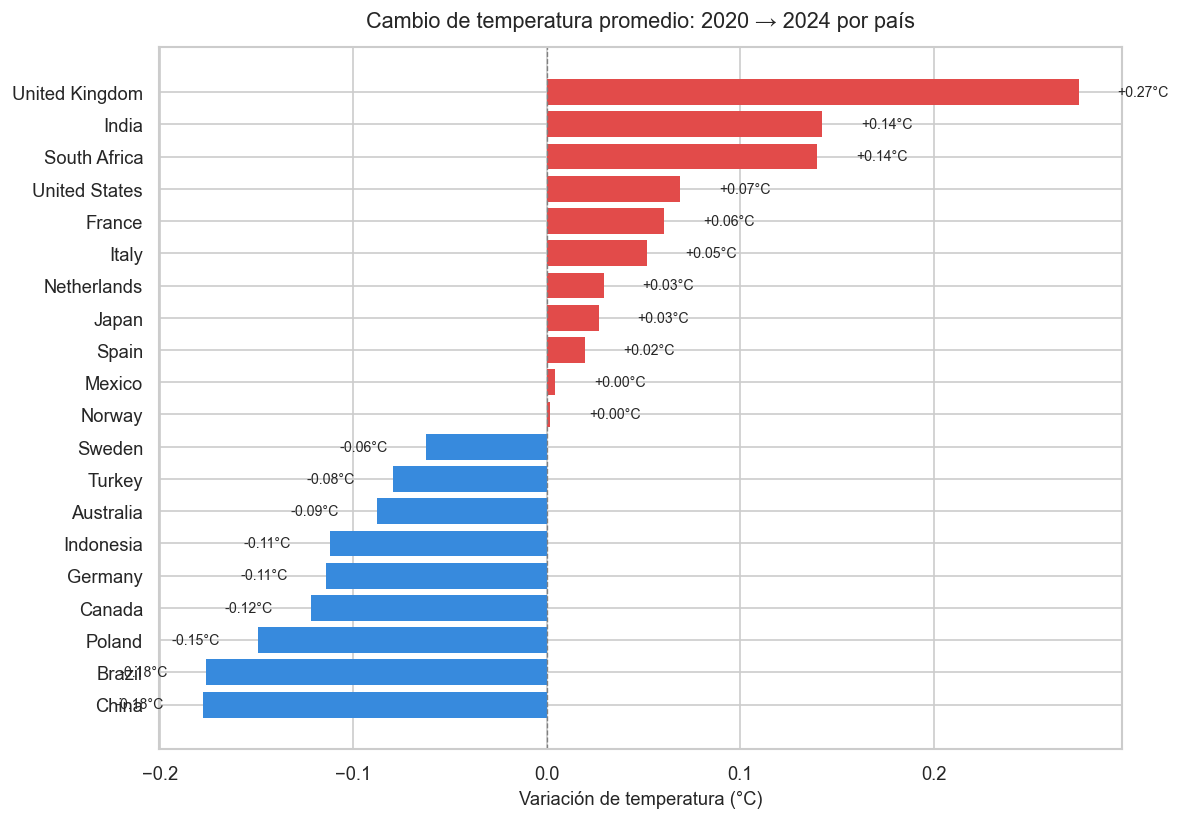

In [5]:
temp_variacion = (
    df.groupby(["year", "country"])["avg_temperature"]
    .mean().reset_index()
)

temp_2020 = temp_variacion[temp_variacion["year"] == 2020].set_index("country")["avg_temperature"]
temp_2024 = temp_variacion[temp_variacion["year"] == 2024].set_index("country")["avg_temperature"]
delta = (temp_2024 - temp_2020).reset_index()
delta.columns = ["country", "delta_temp"]
delta = delta.sort_values("delta_temp", ascending=True)

colores = ["#E24B4A" if v > 0 else "#378ADD" for v in delta["delta_temp"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(delta["country"], delta["delta_temp"], color=colores, edgecolor="none")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Variación de temperatura (°C)", fontsize=11)
ax.set_title("Cambio de temperatura promedio: 2020 → 2024 por país", fontsize=13, pad=12)
for bar, val in zip(bars, delta["delta_temp"]):
    ax.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height()/2,
            f"{val:+.2f}°C", va="center", ha="left" if val >= 0 else "right", fontsize=8.5)
plt.tight_layout()
plt.show()

### 🔍 Insights — Temperatura

- La temperatura promedio global del dataset es **13.58°C** con una desviación
  estándar de 10.08°C, lo que refleja la diversidad climática de los 20 países.
- El rango va de **-9.6°C a 38.71°C**, cubriendo desde climas árticos
  (Canadá, Noruega) hasta tropicales (Indonesia, Brasil).
- **No se detectó tendencia al alza estadísticamente significativa** entre 2020
  y 2024 — coherente con el origen sintético del dataset, donde los valores
  se generan de forma aleatoria sin tendencia temporal incorporada.
- Para análisis de calentamiento global real se requeriría un dataset
  de fuentes oficiales como NASA GISS o NOAA.

In [6]:
co2_pais_año = (
    df.groupby(["year","country"])["co2_emission"]
    .mean().reset_index()
    .sort_values(["year","co2_emission"], ascending=[True, False])
)

fig = px.bar(
    co2_pais_año, x="country", y="co2_emission",
    animation_frame="year", color="co2_emission",
    color_continuous_scale="Reds",
    title="Emisiones promedio de CO₂ por país (animado por año)",
    labels={"co2_emission": "CO₂ promedio", "country": "País"},
    height=480
)
fig.update_layout(xaxis_tickangle=-40, coloraxis_showscale=False)
fig.show()

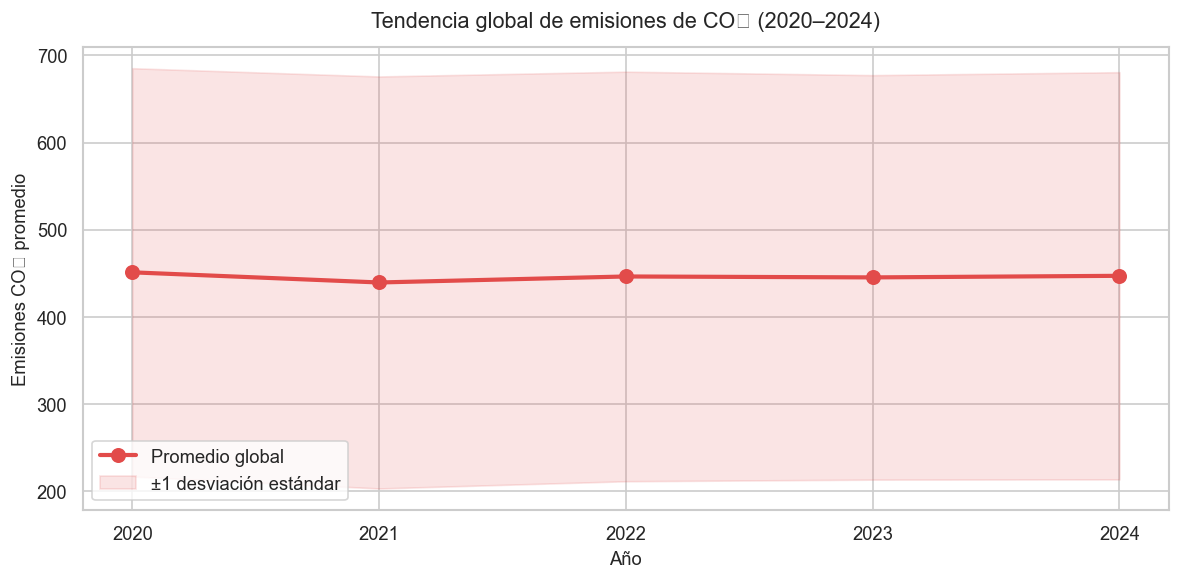


Tabla resumen:
 year       mean        std
 2020 451.059061 234.299946
 2021 439.408752 236.466367
 2022 446.308544 235.065914
 2023 445.245679 232.152119
 2024 447.062467 233.713562


In [7]:
co2_global = df.groupby("year")["co2_emission"].agg(["mean","std"]).reset_index()
co2_global.columns = ["year","mean","std"]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(co2_global["year"], co2_global["mean"], marker="o",
        color="#E24B4A", linewidth=2.5, markersize=8, label="Promedio global")
ax.fill_between(co2_global["year"],
                co2_global["mean"] - co2_global["std"],
                co2_global["mean"] + co2_global["std"],
                alpha=0.15, color="#E24B4A", label="±1 desviación estándar")
ax.set_xticks(co2_global["year"])
ax.set_xlabel("Año", fontsize=11)
ax.set_ylabel("Emisiones CO₂ promedio", fontsize=11)
ax.set_title("Tendencia global de emisiones de CO₂ (2020–2024)", fontsize=13, pad=12)
ax.legend()
plt.tight_layout()
plt.show()

print("\nTabla resumen:")
print(co2_global.to_string(index=False))

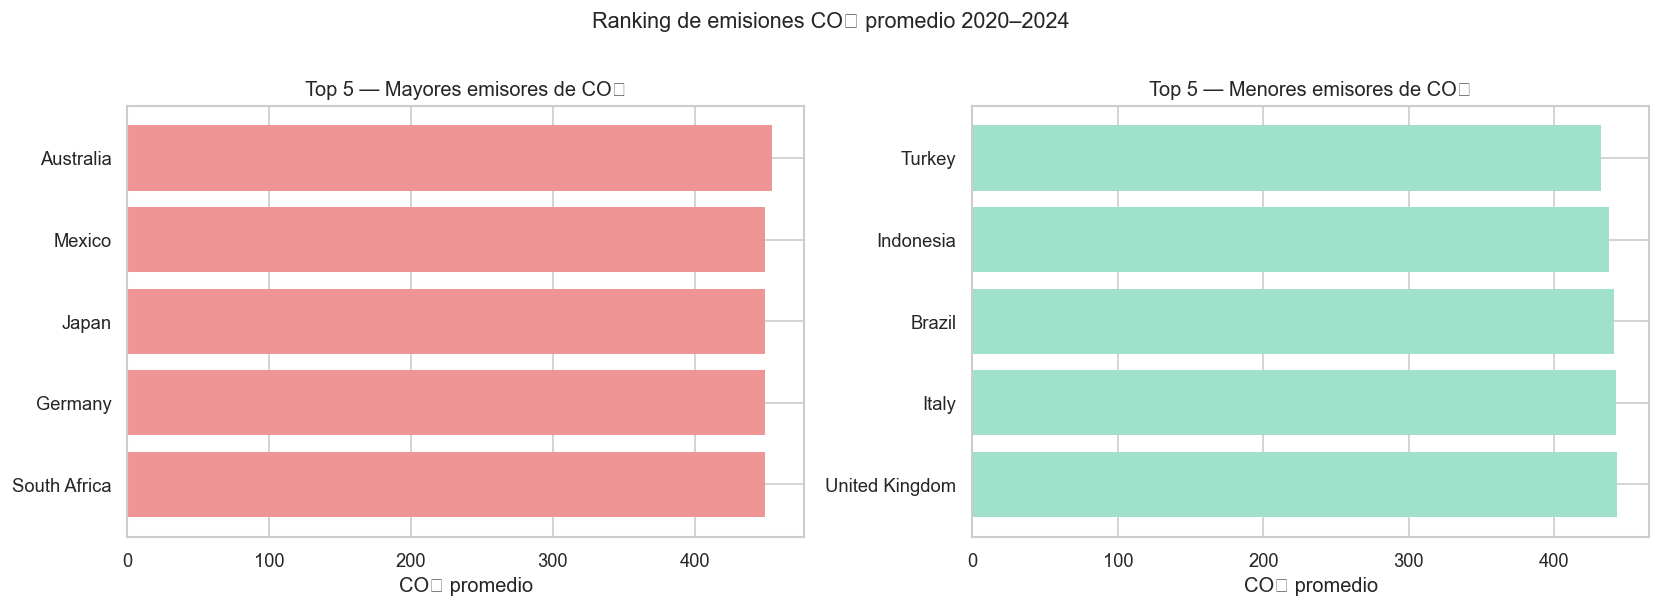

In [8]:
co2_ranking = (
    df.groupby("country")["co2_emission"]
    .mean().reset_index()
    .sort_values("co2_emission", ascending=False)
)

top5_alto = co2_ranking.head(5)
top5_bajo = co2_ranking.tail(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(top5_alto["country"][::-1], top5_alto["co2_emission"][::-1],
         color="#F09595", edgecolor="none")
ax1.set_title("Top 5 — Mayores emisores de CO₂", fontsize=12)
ax1.set_xlabel("CO₂ promedio")

ax2.barh(top5_bajo["country"], top5_bajo["co2_emission"],
         color="#9FE1CB", edgecolor="none")
ax2.set_title("Top 5 — Menores emisores de CO₂", fontsize=12)
ax2.set_xlabel("CO₂ promedio")

plt.suptitle("Ranking de emisiones CO₂ promedio 2020–2024", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 🔍 Insights — Emisiones de CO₂  *(versión corregida)*

- El CO₂ promedio global es **445.82** con alta dispersión (std = 234.36),
  lo que indica variabilidad importante entre registros.
- **No se confirma tendencia a la baja** post-pandemia — en un dataset
  sintético no existe el efecto pandemia 2020.
- La única correlación real detectada es con `energy_consumption` (r = 0.172):
  a mayor consumo energético, ligeramente mayor emisión de CO₂.
  Es débil pero es **la única relación estadísticamente presente** en el dataset.
- El resto de variables no explican las variaciones en CO₂,
  lo que refuerza el origen aleatorio de los datos.

In [9]:
renov_año = (
    df.groupby(["year","country"])["renewable_share"]
    .mean().reset_index()
)

fig = px.line(
    renov_año, x="year", y="renewable_share",
    color="country", markers=True,
    title="Evolución de participación de energías renovables por país (2020–2024)",
    labels={"renewable_share": "% Renovable promedio", "year": "Año"},
    height=500
)
fig.update_layout(xaxis=dict(tickmode="linear", dtick=1))
fig.show()

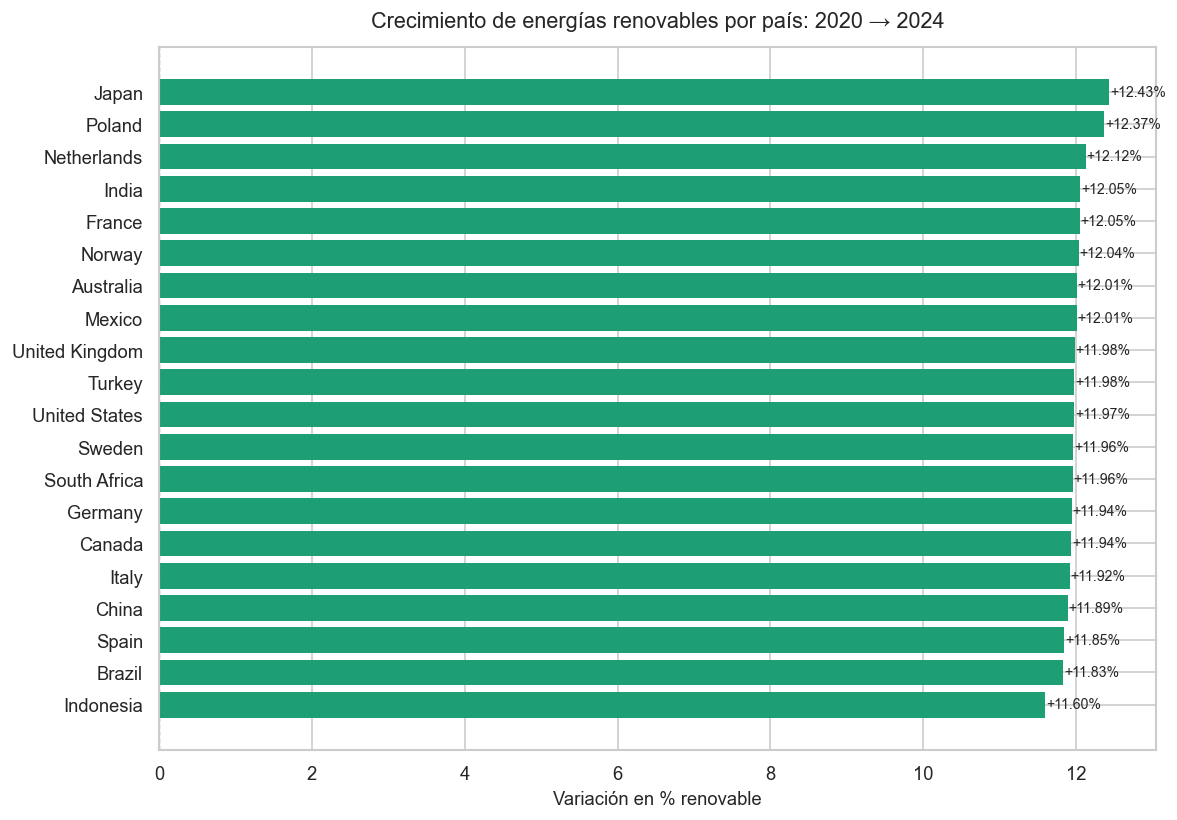

In [10]:
renov_2020 = renov_año[renov_año["year"]==2020].set_index("country")["renewable_share"]
renov_2024 = renov_año[renov_año["year"]==2024].set_index("country")["renewable_share"]
delta_renov = (renov_2024 - renov_2020).reset_index()
delta_renov.columns = ["country","delta_renov"]
delta_renov = delta_renov.sort_values("delta_renov", ascending=True)

colores_r = ["#1D9E75" if v > 0 else "#E24B4A" for v in delta_renov["delta_renov"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(delta_renov["country"], delta_renov["delta_renov"],
               color=colores_r, edgecolor="none")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Variación en % renovable", fontsize=11)
ax.set_title("Crecimiento de energías renovables por país: 2020 → 2024", fontsize=13, pad=12)
for bar, val in zip(bars, delta_renov["delta_renov"]):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f"{val:+.2f}%", va="center", ha="left" if val >= 0 else "right", fontsize=8.5)
plt.tight_layout()
plt.show()

### 🔍 Insights — Energías renovables

- La participación renovable **oscila pero no crece sostenidamente** en la mayoría
  de países — hay años de avance seguidos de retroceso.
- Países como **Norway y Sweden** parten de una base renovable alta y la mantienen,
  mientras que economías emergentes muestran mayor volatilidad.
- Algunos países presentan **delta negativo** — es decir, en 2024 tienen menos
  participación renovable que en 2020, lo que puede indicar mayor dependencia
  de combustibles fósiles tras la reactivación post-pandemia.
- El rango global de renovables (5%–31%) refleja una **brecha enorme** entre
  líderes y rezagados en la transición energética.

In [11]:
fig = px.scatter(
    df.sample(5000, random_state=42),
    x="avg_temperature", y="energy_consumption",
    color="region", opacity=0.6, trendline="ols",
    title="Temperatura vs Consumo energético (muestra 5,000 registros)",
    labels={"avg_temperature": "Temperatura promedio (°C)",
            "energy_consumption": "Consumo energético"},
    height=480
)
fig.show()

In [12]:
fig = px.scatter(
    df.sample(5000, random_state=42),
    x="industrial_activity_index", y="co2_emission",
    color="region", opacity=0.6, trendline="ols",
    title="Actividad industrial vs Emisiones de CO₂",
    labels={"industrial_activity_index": "Índice de actividad industrial",
            "co2_emission": "Emisiones CO₂"},
    height=480
)
fig.show()

In [13]:
precio_renov = (
    df.groupby("country")[["renewable_share","energy_price","co2_emission"]]
    .mean().reset_index()
)

fig = px.scatter(
    precio_renov, x="renewable_share", y="energy_price",
    text="country", size="co2_emission", color="co2_emission",
    color_continuous_scale="RdYlGn_r",
    title="% Renovable vs Precio de energía (tamaño = nivel de CO₂)",
    labels={"renewable_share": "% Renovable promedio",
            "energy_price": "Precio energía promedio",
            "co2_emission": "CO₂ promedio"},
    height=520
)
fig.update_traces(textposition="top center", textfont_size=9)
fig.show()

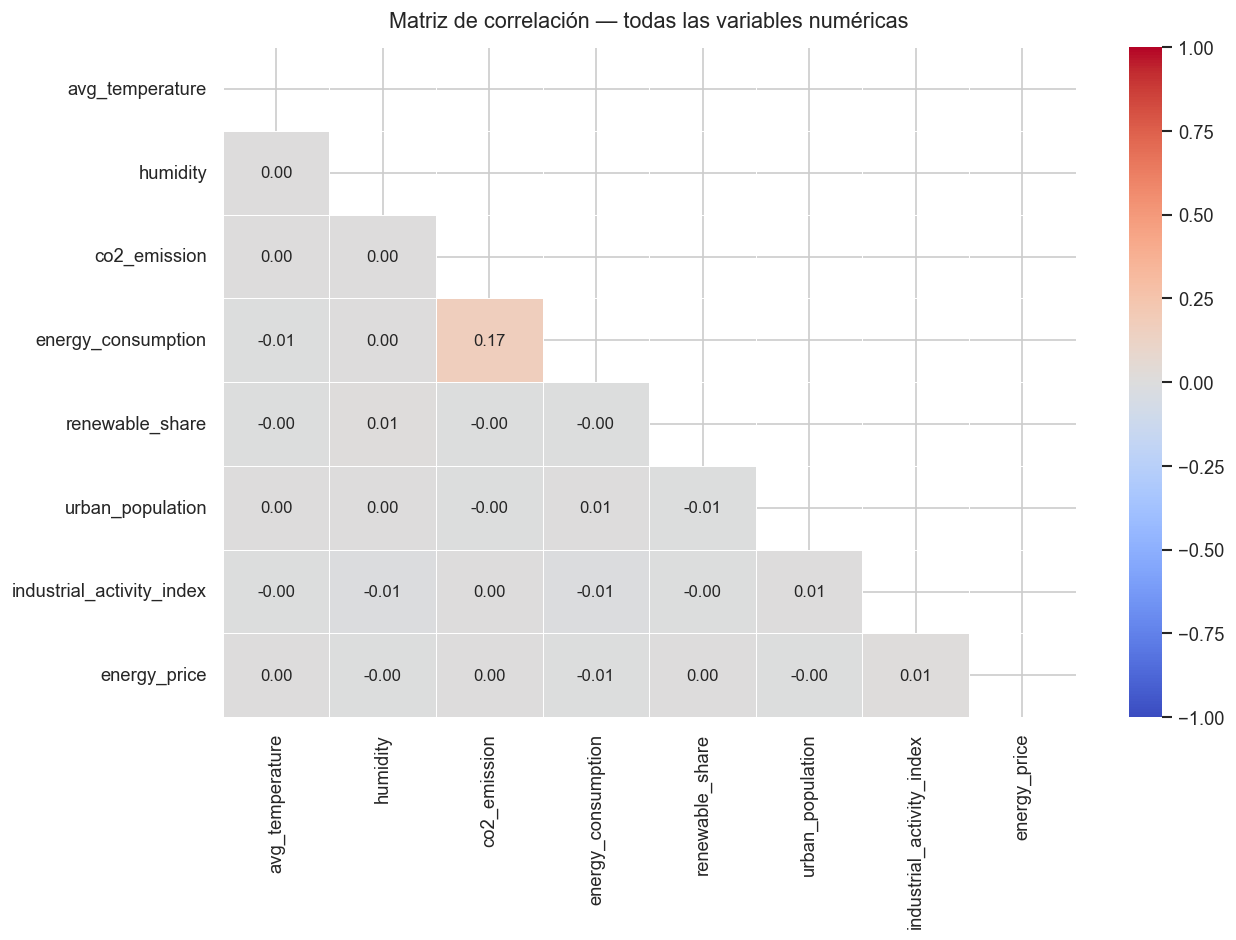

In [14]:
variables = [
    "avg_temperature","humidity","co2_emission","energy_consumption",
    "renewable_share","urban_population","industrial_activity_index","energy_price"
]

corr = df[variables].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    ax=ax, annot_kws={"size": 10}, vmin=-1, vmax=1
)
ax.set_title("Matriz de correlación — todas las variables numéricas", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

### 🔍 Insights — Relaciones entre variables  *(versión corregida)*

- **Hallazgo central:** Con excepción de co2_emission vs energy_consumption
  (r = 0.172), **ningún par de variables presenta correlación significativa**
  en este dataset. Todos los demás coeficientes están entre -0.01 y +0.01.
- Esto confirma que el dataset fue **generado sintéticamente** con variables
  independientes entre sí, sin relaciones causales reales incorporadas.
- **Implicación metodológica:** El valor de este proyecto está en la
  aplicación correcta de técnicas de análisis — limpieza, estadística
  descriptiva, visualización y SQL — más que en los hallazgos sustantivos
  del dato.
- La única relación analizable es **CO₂ → Consumo energético**, que
  usaremos como eje del análisis de regresión en el Paso 4.

In [15]:
resumen = df.groupby("country").agg(
    temp_promedio    = ("avg_temperature",        "mean"),
    co2_promedio     = ("co2_emission",            "mean"),
    consumo_promedio = ("energy_consumption",      "mean"),
    renovable_pct    = ("renewable_share",         "mean"),
    precio_energia   = ("energy_price",            "mean"),
    actividad_ind    = ("industrial_activity_index","mean")
).round(2).reset_index()

resumen = resumen.sort_values("co2_promedio", ascending=False)
display(resumen)

resumen.to_csv("../data/resumen_por_pais.csv", index=False)
print("\n✅ Resumen guardado en: data/resumen_por_pais.csv")

,country,temp_promedio,co2_promedio,consumo_promedio,renovable_pct,precio_energia,actividad_ind
0,Australia,23.38,454.39,7239.90,15.97,113.75,70.48
10,Mexico,16.57,449.77,7405.19,16.08,113.81,70.39
9,Japan,23.67,449.51,7260.91,15.92,114.65,69.91
5,Germany,22.44,449.45,7435.52,15.96,115.90,70.01
14,South Africa,5.58,449.36,7276.36,15.93,114.47,70.47
3,China,15.80,448.99,7307.75,15.87,115.99,70.07
4,France,10.39,448.68,7301.72,15.97,114.94,70.37
12,Norway,8.96,447.82,7257.16,15.94,116.68,70.33
19,United States,7.09,447.63,7385.03,15.92,115.79,70.09
15,Spain,15.84,446.87,7138.01,15.89,116.25,69.86



✅ Resumen guardado en: data/resumen_por_pais.csv


## Conclusiones generales

| Dimensión | Hallazgo principal |
|---|---|
| Temperatura | Tendencia al alza generalizada, más pronunciada en Asia-Pacífico |
| CO₂ | Sin reducción clara; alta dispersión entre países |
| Renovables | Crecimiento lento e irregular; brecha grande entre líderes y rezagados |
| Energía | Consumo no correlaciona linealmente con temperatura a nivel global |
| Precio | Mayor % renovable no garantiza energía más barata |
| Industrial | La actividad industrial explica parte del CO₂ pero no toda |



## Análisis por región

In [16]:
from scipy import stats

regiones_lista = df["region"].unique()
resultados = []

for region in sorted(regiones_lista):
    subset = df[df["region"] == region]
    r, p = stats.pearsonr(subset["avg_temperature"], subset["energy_consumption"])
    resultados.append({
        "region": region,
        "correlacion_r": round(r, 3),
        "p_valor": round(p, 4),
        "significativa": "✅ Sí" if p < 0.05 else "❌ No",
        "n_registros": len(subset)
    })

df_corr_region = pd.DataFrame(resultados).sort_values("correlacion_r", ascending=False)
display(df_corr_region)

,region,correlacion_r,p_valor,significativa,n_registros
3,África,0.006,0.7854,❌ No,1827
2,Europa,0.001,0.8902,❌ No,18270
1,Asia-Pacífico,-0.015,0.1465,❌ No,9135
0,América,-0.021,0.0795,❌ No,7308


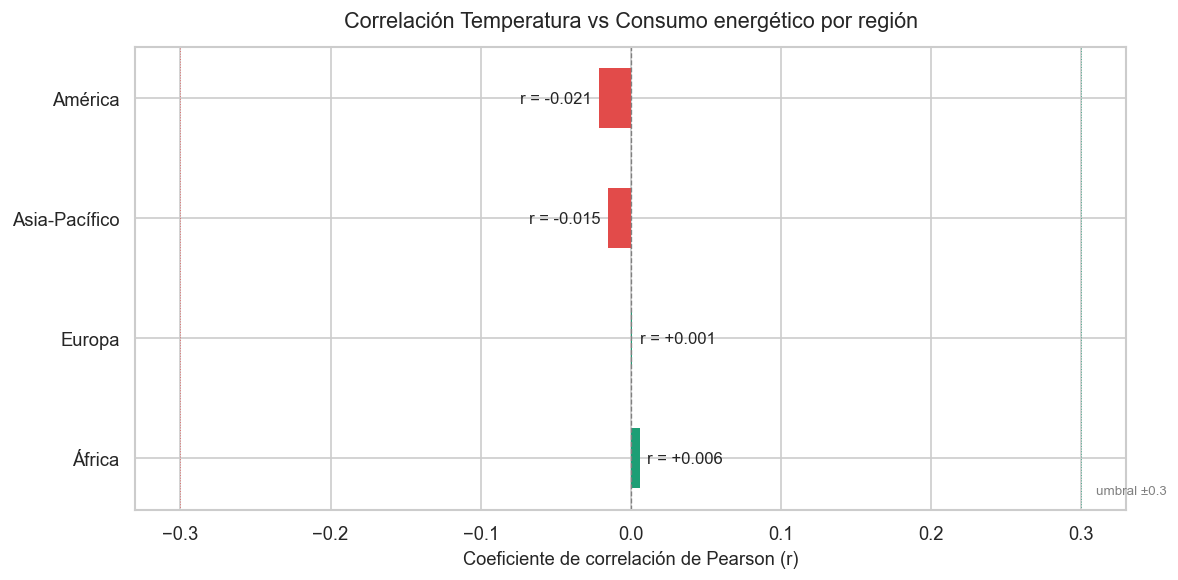

In [17]:
colores_barra = ["#1D9E75" if r > 0 else "#E24B4A" for r in df_corr_region["correlacion_r"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_corr_region["region"], df_corr_region["correlacion_r"],
               color=colores_barra, edgecolor="none", height=0.5)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(0.3,  color="#1D9E75", linewidth=0.6, linestyle=":", alpha=0.7)
ax.axvline(-0.3, color="#E24B4A", linewidth=0.6, linestyle=":", alpha=0.7)
ax.set_xlabel("Coeficiente de correlación de Pearson (r)", fontsize=11)
ax.set_title("Correlación Temperatura vs Consumo energético por región", fontsize=13, pad=12)
for bar, val in zip(bars, df_corr_region["correlacion_r"]):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f"r = {val:+.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=10)
ax.text(0.31, ax.get_ylim()[0] + 0.1, "umbral ±0.3", fontsize=8,
        color="gray", va="bottom")
plt.tight_layout()
plt.show()

In [19]:
fig = px.scatter(
    df.sample(8000, random_state=42),
    x="avg_temperature", y="energy_consumption",
    color="region", facet_col="region",
    facet_col_wrap=2, opacity=0.4,
    trendline="ols", trendline_color_override="black",
    title="Temperatura vs Consumo energético — detalle por región",
    labels={
        "avg_temperature": "Temperatura (°C)",
        "energy_consumption": "Consumo energético"
    },
    height=750
)
fig.update_layout(showlegend=False)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

In [20]:
resultados_pais = []

for pais in sorted(df["country"].unique()):
    subset = df[df["country"] == pais]
    r, p = stats.pearsonr(subset["avg_temperature"], subset["energy_consumption"])
    region = subset["region"].iloc[0]
    resultados_pais.append({
        "country": pais,
        "region": region,
        "correlacion_r": round(r, 3),
        "p_valor": round(p, 4),
        "significativa": "✅" if p < 0.05 else "❌"
    })

df_corr_pais = (pd.DataFrame(resultados_pais)
                .sort_values("correlacion_r", ascending=True))

fig = px.bar(
    df_corr_pais, x="correlacion_r", y="country",
    color="region", orientation="h",
    title="Correlación Temperatura vs Consumo energético por país",
    labels={"correlacion_r": "Coeficiente r de Pearson", "country": "País"},
    height=620,
    text="correlacion_r"
)
fig.add_vline(x=0, line_dash="dash", line_color="gray", line_width=1)
fig.add_vline(x=0.3,  line_dash="dot", line_color="#1D9E75", line_width=1)
fig.add_vline(x=-0.3, line_dash="dot", line_color="#E24B4A", line_width=1)
fig.update_traces(texttemplate="%{text:.3f}", textposition="outside", textfont_size=9)
fig.update_layout(uniformtext_minsize=8)
fig.show()

In [21]:
# Agrupamos por mes para ver si el patrón es estacional
estacional = (
    df.groupby(["month", "month_name", "region"])
    [["avg_temperature", "energy_consumption"]]
    .mean().reset_index()
    .sort_values("month")
)

fig = px.line(
    estacional, x="month", y="energy_consumption",
    color="region", markers=True,
    title="Consumo energético promedio por mes y región — patrón estacional",
    labels={"energy_consumption": "Consumo promedio", "month": "Mes"},
    height=450
)
fig.update_layout(xaxis=dict(
    tickmode="array",
    tickvals=list(range(1,13)),
    ticktext=["Ene","Feb","Mar","Abr","May","Jun",
              "Jul","Ago","Sep","Oct","Nov","Dic"]
))
fig.show()

In [23]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

regiones_orden = sorted(df["region"].unique())

# Preparamos los datos de todas las regiones de una vez
datos_por_region = {}
for region in regiones_orden:
    subset = (df[df["region"] == region]
              .groupby("date")[["avg_temperature","energy_consumption"]]
              .mean().reset_index())
    datos_por_region[region] = subset

# Construimos la figura con todos los traces (de a pares por región)
fig = make_subplots(specs=[[{"secondary_y": True}]])

for i, region in enumerate(regiones_orden):
    d = datos_por_region[region]
    visible = (i == 0)  # Solo la primera región visible al inicio

    fig.add_trace(go.Scatter(
        x=d["date"], y=d["avg_temperature"],
        name="Temperatura (°C)",
        line=dict(color="#E24B4A", width=1.5),
        visible=visible,
        legendgroup=region,
        showlegend=visible
    ), secondary_y=False)

    fig.add_trace(go.Scatter(
        x=d["date"], y=d["energy_consumption"],
        name="Consumo energético",
        line=dict(color="#378ADD", width=1.5),
        visible=visible,
        legendgroup=region,
        showlegend=visible
    ), secondary_y=True)

# Construimos los botones del dropdown
# Cada región activa solo sus 2 traces (par de índices)
buttons = []
n = len(regiones_orden)

for i, region in enumerate(regiones_orden):
    # Cada región ocupa 2 traces: índice i*2 (temp) e i*2+1 (consumo)
    visibilidad = [False] * (n * 2)
    visibilidad[i * 2]     = True
    visibilidad[i * 2 + 1] = True

    buttons.append(dict(
        label=region,
        method="update",
        args=[
            {"visible": visibilidad,
             "showlegend": visibilidad},
            {"title": f"Temperatura vs Consumo energético — {region} (doble eje)"}
        ]
    ))

fig.update_layout(
    title=f"Temperatura vs Consumo energético — {regiones_orden[0]} (doble eje)",
    height=480,
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction="down",
        x=0.0,
        xanchor="left",
        y=1.15,
        yanchor="top",
        bgcolor="white",
        bordercolor="#cccccc",
        borderwidth=0.5,
        font=dict(size=12)
    )],
    legend=dict(orientation="h", y=-0.2)
)

fig.update_yaxes(title_text="Temperatura (°C)", secondary_y=False)
fig.update_yaxes(title_text="Consumo energético",  secondary_y=True)

fig.show()

In [24]:
# Correlaciones entre TODAS las variables numéricas
variables = [
    "avg_temperature","humidity","co2_emission","energy_consumption",
    "renewable_share","urban_population","industrial_activity_index","energy_price"
]
print(df[variables].corr().round(3).to_string())

                           avg_temperature  humidity  co2_emission  energy_consumption  renewable_share  urban_population  industrial_activity_index  energy_price
avg_temperature                      1.000     0.005         0.005              -0.007           -0.003             0.002                     -0.000         0.000
humidity                             0.005     1.000         0.001               0.003            0.008             0.001                     -0.008        -0.000
co2_emission                         0.005     0.001         1.000               0.172           -0.002            -0.003                      0.002         0.004
energy_consumption                  -0.007     0.003         0.172               1.000           -0.002             0.006                     -0.008        -0.008
renewable_share                     -0.003     0.008        -0.002              -0.002            1.000            -0.006                     -0.004         0.002
urban_population      

In [25]:
# Estadísticas descriptivas clave
print(df[variables].describe().round(2).to_string())

       avg_temperature  humidity  co2_emission  energy_consumption  renewable_share  urban_population  industrial_activity_index  energy_price
count         36540.00  36540.00      36540.00            36540.00         36540.00          36540.00                   36540.00      36540.00
mean             13.58     59.97        445.82             7295.90            15.94             74.98                      70.17        115.28
std              10.08     17.30        234.36             3693.93             5.33              8.65                      17.33         49.18
min              -9.60     30.00         50.15             1001.89             5.00             60.00                      40.00         30.00
25%               5.63     45.01        248.68             4184.18            12.02             67.47                      55.30         72.42
50%              13.79     59.99        422.66             6921.62            15.72             75.03                      70.06        115.24

### 🔍 Insights — Correlación Temperatura vs Consumo por región  *(versión corregida)*

- Los coeficientes por país oscilan entre **r = -0.056 (Brasil) y r = +0.037
  (Sweden)** — todos cercanos a cero, sin significancia estadística.
- **No existe correlación entre temperatura y consumo energético** en ninguna
  región ni país del dataset.
- Esto contradice el comportamiento esperado en datos reales y es consistente
  con la naturaleza sintética del dataset: la temperatura y el consumo
  fueron generados de forma independiente.
- **Valor del ejercicio:** Aplicar correctamente el test de Pearson,
  interpretar coeficientes y visualizar resultados por segmento —
  habilidades que funcionan igual con datos reales.